### Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
from datetime import datetime

import torch as torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

# utils
from models.fs_model import Model
from data.dataset_modul import Dataset
from utils.preprocessing import preprocessing
from utils.utils import train_model, train_rf, combined_metrics, eval_rf, plot_tsne_embeddings

### Settings

In [2]:
# seed settings
seed = 42 #7270 

In [3]:
# cuda settings
if torch.cuda.is_available():
    device_id = torch.cuda.current_device()
    device = torch.device('cuda:%d' % device_id)
    print(torch.cuda.get_device_name(device_id))
else:
    device = torch.device('cpu')

NVIDIA GeForce RTX 4060 Ti


# 1. Load Dataset

In [4]:
# datset paths
sider_path = "data/datasets/sider.csv"
tox_path = "data/datasets/toxcast_data.csv"

In [5]:
dataset = pd.read_csv(sider_path)

nMeas = len([v for v in dataset.iloc[:, 1:].values.flatten() if str(v) != 'nan']) 
nNone =  dataset.isna().sum().sum()

print(f'nMols: {dataset.shape[0]}\nnTasks: {dataset.shape[1]}\nnNone: {nNone}\nnMeasurments: {nMeas}')

#dataset.head() 

nMols: 1427
nTasks: 28
nNone: 0
nMeasurments: 38529


### 1.1 Additional Information

In [6]:
# Percentage of actives and inactives per task

show = False

percentage_df = pd.DataFrame()

if show:    
    
    for col in dataset.columns[1:]:
        # Calculate the percentages of 0s and 1s
        value_counts = dataset[col].value_counts(normalize=True) * 100
        # Store the result in the DataFrame
        percentage_df[col] = value_counts
            
    percentage_df = percentage_df.reset_index(drop=True)
percentage_df

""


In [7]:
# Overall percentage of actives and inactives

show = False

if show:
    task_columns = sider.columns[1:]
    
    # Combine all task columns into a single series
    all_tasks_combined = sider[task_columns].values.flatten()
    
    # Calculate the overall percentage of 0s and 1s
    overall_percentages = pd.Series(all_tasks_combined).value_counts(normalize=True) * 100
    
    # Convert to DataFrame for better visualization
    overall_percentages_df = overall_percentages.to_frame(name='Overall Percentage').T
    
    # Display the overall percentages
    print(overall_percentages_df)

### 1.2 Create Triplet-DF

In [8]:
# create triplet-df

triplets = [(i,j,row.iloc[j]) for i,row in dataset.iterrows() for j in range(1,len(row))]
triplet_df = pd.DataFrame(triplets, columns=['mol_id', 'target_id', 'label']) 

#triplet_df.head()

# 2. Preprocessing

### 2.1 Datasplit & Preprocessing

In [9]:
data, dataset, train_triplet, val_triplet, test_triplet = preprocessing(dataset, triplet_df, seed)

Preprocessing done!



In [10]:
# dataset information after preprocessing
nMeas = len([v for v in dataset.iloc[:, 1:].values.flatten() if str(v) != 'nan']) 
nNone =  dataset.isna().sum().sum()
print(f'nMols: {dataset.shape[0]}\nnTasks: {dataset.shape[1]-1}\nnNone: {nNone}\nnMeasurments: {nMeas}')
dataset.head() 

nMols: 1427
nTasks: 27
nNone: 0
nMeasurments: 38529


,smiles,Hepatobiliary disorders,Metabolism and nutrition disorders,Product issues,Eye disorders,Investigations,Musculoskeletal and connective tissue disorders,Gastrointestinal disorders,Social circumstances,Immune system disorders,...,"Congenital, familial and genetic disorders",Infections and infestations,"Respiratory, thoracic and mediastinal disorders",Psychiatric disorders,Renal and urinary disorders,"Pregnancy, puerperium and perinatal conditions",Ear and labyrinth disorders,Cardiac disorders,Nervous system disorders,"Injury, poisoning and procedural complications"
0,C(CNCCNCCNCCN)N,1,1,0,0,1,1,1,0,0,...,0,0,1,1,0,0,1,1,1,0
1,CC(C)(C)C1=CC(=C(C=C1NC(=O)C2=CNC3=CC=CC=C3C2=...,0,1,0,0,1,1,1,0,0,...,0,1,1,0,0,0,1,0,1,0
2,CC[C@]12CC(=C)[C@H]3[C@H]([C@@H]1CC[C@]2(C#C)O...,0,1,0,1,1,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
3,CCC12CC(=C)C3C(C1CC[C@]2(C#C)O)CCC4=CC(=O)CCC34,1,1,0,1,1,1,1,0,1,...,1,1,1,1,1,1,0,0,1,1
4,C1C(C2=CC=CC=C2N(C3=CC=CC=C31)C(=O)N)O,1,1,0,1,1,1,1,0,1,...,0,1,1,1,0,0,1,0,1,0


### 2.2 Defines Sets

In [11]:
train_set = Dataset(data, dataset, train_triplet, supp=8, seed=seed)
val_set   = Dataset(data, dataset, val_triplet, supp=8, train = False, seed=seed)
test_set  = Dataset(data, dataset, test_triplet, supp=8, train = False, seed=seed)

# 3. Model

### 3.1 Initialize Model

In [12]:
# read model config 
with open("configs/fs_config.json") as json_file:
    default_config = json.load(json_file)

model_config = default_config 
BATCH_SIZE = model_config["batch_size"] # 16,32,64

In [13]:
model_params = {k: v for k, v in model_config.items() if k not in ['opt_lr', 'weight_decay','batch_size']}

model = Model(**model_params) 

criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=model_config["opt_lr"], weight_decay=model_config["weight_decay"])

model.to(device)

Model(
  (encoder): Sequential(
    (0): Linear(in_features=2248, out_features=1124, bias=True)
    (1): SELU()
    (2): AlphaDropout(p=0.1, inplace=False)
    (3): Linear(in_features=1124, out_features=1124, bias=True)
    (4): SELU()
    (5): AlphaDropout(p=0.1, inplace=False)
    (6): Linear(in_features=1124, out_features=1124, bias=True)
  )
  (ln): LayerNorm((1124,), eps=1e-05, elementwise_affine=False)
  (cosine): CosineSimilarity()
)

### 3.3 Initialize Dataloaders

In [14]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set , batch_size=BATCH_SIZE, shuffle=True)

# 4.Training

### 4.1 Train Config & Savepath

In [15]:
# setup savepath for tensorboardlogs
parent_dir = "runs/pw_notebook/"

if not os.path.exists(parent_dir):
    os.makedirs(parent_dir)

# initialize writer
log_dir = os.path.join(parent_dir, f"{datetime.now().strftime('%d-%m-%Y_%Hh-%Mm')}_{seed=}")
writer = SummaryWriter(log_dir=log_dir)

# setup savepath for model
model_parent = "trainedModels/pw_notebook/"

if not os.path.exists(model_parent):
    os.makedirs(model_parent)
    
save_path =  os.path.join(model_parent, f"fsModel_{seed=}.mdl")

In [16]:
train_config = {
    "model": model,
    "criterion": criterion,
    "optimizer": optimizer,
    "max_epochs": 50,
    "patience": 4,
    "log_interval": 100,
    "val_interval": 4, # set higher to fasten up the process of training
    "save_path": save_path
}

### 4.2 Trainprocess

In [17]:
train_model(train_config, writer, train_loader, val_loader, device, BATCH_SIZE)

epoch:11/50 batches:0700/713 current lr:1.0000e-03 avg-train_loss:0.4011, avg-val_loss:0.5452, val-auc:0.7956, val-dauc_pr:0.1879                                                                                                                                                                                                                                                                               
Finished training...


# 5. Evalutation on Test-Set

In [18]:
model.load_state_dict(torch.load(train_config["save_path"]))

<All keys matched successfully>

### 5.1 Val-Set Evaluation

In [19]:
combined_metrics(model,val_loader,device)

,Accuracy,F1 Score,AUC,D-AUC PR
0,0.7196,0.7955,0.8097,0.2027


### 5.2 Test-Set Evaluation

In [20]:
test_results = combined_metrics(model,test_loader,device)
test_results

,Accuracy,F1 Score,AUC,D-AUC PR
0,0.7563,0.7318,0.8125,0.2071


### 5.3 Save notebook results

In [21]:
# gather configs 
model_config.update({"batch_size": BATCH_SIZE})
used_config = {
    'criterion': {
        'class': criterion.__class__.__name__  # Get criterion class name
    },
    'optimizer': {
        'class': optimizer.__class__.__name__,  # Get optimizer class name
        'defaults': optimizer.defaults  # Extract default parameters
    },
    'model_config': model_config,
    'training_params': {k: v for k, v in train_config.items() if k not in ['model','criterion','optimizer']}
    }

### 5.4 TSNE before and after Training

In [22]:
# get random task id from test set
unique_task_ids = test_triplet['target_id'].unique()  # Get all unique task IDs
random_task_id = np.random.choice(unique_task_ids)
random_task_id

20

In [23]:
# create triplet with only 1 task
single_task_triplet = test_triplet[ test_triplet['target_id'] == random_task_id].reset_index(drop=True)

# create set with only 1 task
single_task_set = Dataset(data, dataset, single_task_triplet, supp=8, train = False, seed=seed)

# set dataloader for only 1 task
single_task_loader = DataLoader(single_task_set, batch_size=1427, shuffle=True)

In [24]:
# get support molecule indexes
support_indexes = single_task_set.get_support_indexes(task=random_task_id)

# create mask
exclude = np.concatenate([ support_indexes['n_indexes'], support_indexes['p_indexes']])
mask = np.ones(data.shape[0], dtype=bool)
mask[exclude] = False

In [25]:
# get embeds
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    encoded_embeds = model.encoder(torch.from_numpy(data[mask]).float().to(device)).cpu().numpy()

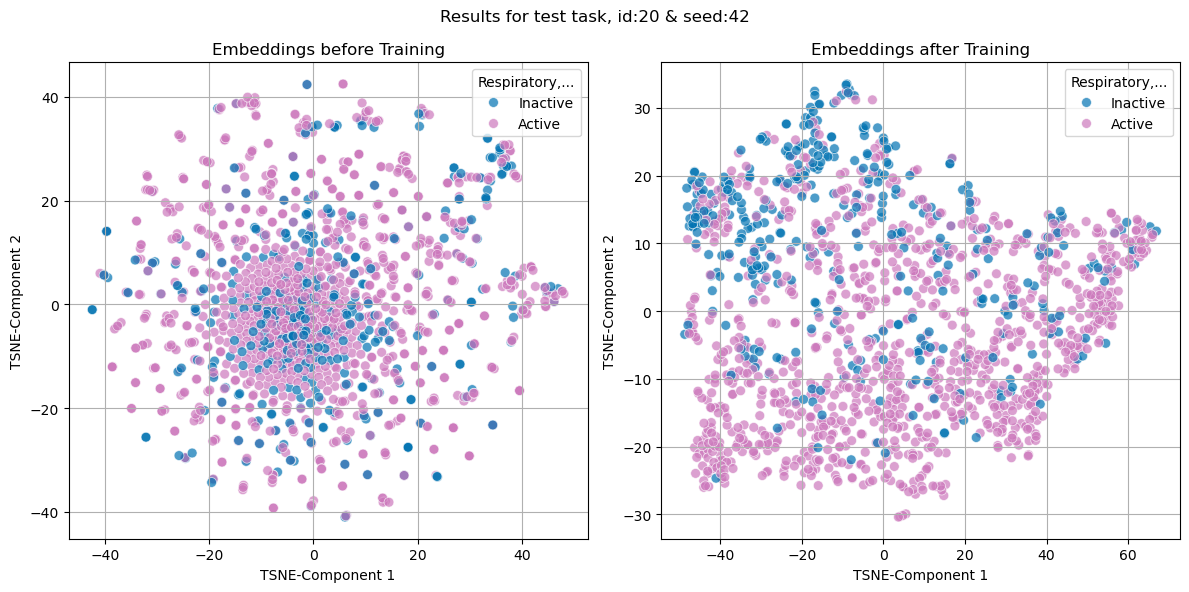

In [26]:
task_name = dataset.columns[random_task_id]
plot_labels = dataset.iloc[:,random_task_id].values[mask]

plot_tsne_embeddings(data[mask], encoded_embeds, plot_labels, task_name, f'Results for test task, id:{random_task_id} & seed:{seed}',seed,save=True)

# 6. Compare to Baseline

### 6.1 RF Training

In [27]:
y_hats_proba, y_hats_class, true_labels = train_rf(dataset, data, test_triplet, seed, 1000, shuffle = True)

### 6.2 Evaluate RF

In [28]:
eval_rf( y_hats_class,true_labels)

,Accuracy,F1 Score,AUC,D-AUC PR
0,0.5184,0.5487,0.5241,0.0073
